In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import random
import warnings
import os
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("=" * 65)
print("PROJECT 3: Mutation Impact Prediction with ESM-2")
print("=" * 65)

Using device: cpu
PROJECT 3: Mutation Impact Prediction with ESM-2


In [2]:
print("\n[1/6] Loading ESM-2 model from HuggingFace...")

from transformers import AutoTokenizer, AutoModelForMaskedLM

MODEL_NAME = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f"  Model: {MODEL_NAME}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Vocabulary size: {tokenizer.vocab_size}")
print(f"  Model loaded to {device}")


[1/6] Loading ESM-2 model from HuggingFace...


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model: facebook/esm2_t6_8M_UR50D
  Parameters: 7,512,474
  Vocabulary size: 33
  Model loaded to cpu


In [3]:
print("\n[2/6] Generating synthetic mutation dataset...")

# Use lambda repressor (PDB: 1LMB) — a well-studied small protein
WILDTYPE_SEQ = (
    "PLSQEAAARVQENYQQQQQQQAAATQAPGAAGQPGAAGQPGAVGADGAGDGEAIQRQLGAGYGA"
    "AAGMGVGGMQPGGMGMGQPGVDPAAVPGDMPAGQSMGQPGAQAPAVMGQPGAQAPAVMGQPAV"
    "MGQPGAVMGQQPLFPSR"
)

WT_SEQ = WILDTYPE_SEQ[:100]  # Take first 100 aa for manageable size
SEQ_LEN = len(WT_SEQ)
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')

print(f"  Wild-type protein: Lambda Repressor (1LMB-like)")
print(f"  Sequence length: {SEQ_LEN} aa")
print(f"  Sequence: {WT_SEQ[:50]}...{WT_SEQ[-50:]}")


[2/6] Generating synthetic mutation dataset...
  Wild-type protein: Lambda Repressor (1LMB-like)
  Sequence length: 100 aa
  Sequence: PLSQEAAARVQENYQQQQQQQAAATQAPGAAGQPGAAGQPGAVGADGAGD...GEAIQRQLGAGYGAAAGMGVGGMQPGGMGMGQPGVDPAAVPGDMPAGQSM


In [4]:
def blosum62_score(aa1, aa2):
    """Simplified BLOSUM62-like scoring."""
    # Positive = conservative substitution, Negative = radical
    groups = {
        'AG': 3, 'ST': 3, 'DE': 3, 'NQ': 3, 'KR': 3, 'ILMV': 3, 'FYW': 3, 'P': 0
    }
    for group, val in groups.items():
        if aa1 in group and aa2 in group:
            return val
    return -2  # non-conservative

mutation_data = []
for _ in range(300):
    pos = random.randint(0, SEQ_LEN - 1)
    wt_aa = WT_SEQ[pos]
    mut_aa = random.choice([a for a in AMINO_ACIDS if a != wt_aa])

    # Simulate DDG (kcal/mol): the more radical the change, the more destabilizing
    similarity = blosum62_score(wt_aa, mut_aa)
    # Random noise + bias from substitution severity
    ddg = -0.3 * similarity + np.random.normal(0, 0.5)
    # Clamp to realistic range
    ddg = np.clip(ddg, -2.0, 4.0)

    mutation_data.append({
        'position': pos,
        'wt_aa': wt_aa,
        'mut_aa': mut_aa,
        'ddg': ddg,
        'label': 'destabilizing' if ddg > 1.0 else ('stabilizing' if ddg < -1.0 else 'neutral')
    })

df = pd.DataFrame(mutation_data)
print(f"\n  Generated {len(df)} mutations:")
print(f"    Stabilizing  (DDG < -1.0): {(df['label']=='stabilizing').sum()}")
print(f"    Neutral      (|DDG|<=1.0): {(df['label']=='neutral').sum()}")
print(f"    Destabilizing(DDG > +1.0): {(df['label']=='destabilizing').sum()}")



  Generated 300 mutations:
    Stabilizing  (DDG < -1.0): 9
    Neutral      (|DDG|<=1.0): 237
    Destabilizing(DDG > +1.0): 54


In [5]:
print("\n[3/6] Running zero-shot mutation effect prediction...")
print("  (Scoring each mutation using ESM-2 log-likelihood ratio)\n")

def score_mutation(sequence, position, mutant_aa, model, tokenizer, device):
    """
    Score a mutation using the masked language model.

    Returns the log-likelihood ratio:
        score = log P(mutant | context) - log P(wildtype | context)
    """
    # Mask the target position in the sequence
    seq_list = list(sequence)
    seq_list[position] = tokenizer.mask_token
    masked_seq = ''.join(seq_list)

    # Tokenize
    inputs = tokenizer(masked_seq, return_tensors='pt').to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0]  # (seq_len+2, vocab)

    # Map token positions: tokens[1:-1] correspond to sequence positions
    # Find the correct token index for the masked position
    tokens = tokenizer.tokenize(masked_seq)
    # Account for special tokens and BPE tokenization
    tokenized = tokenizer(masked_seq, return_tensors='pt')
    input_ids = tokenized['input_ids'][0]

    # For ESM-2 tokenizers, find token boundaries
    tokens_str = tokenizer.convert_ids_to_tokens(input_ids)
    # Find which token ID corresponds to our masked position
    # ESM adds [CLS] at start, so sequence tokens start at index 1
    target_token_idx = None
    tok_count = 0
    for i, tok in enumerate(tokens_str[1:-1], start=1):  # skip [CLS] and [EOS]
        if tok == tokenizer.mask_token:
            if tok_count == position:
                target_token_idx = i
                break
            tok_count += 1

    if target_token_idx is None:
        return 0.0

    wt_id = tokenizer.convert_tokens_to_ids(wildtype_aa) if wildtype_aa != tok else tokenizer.unk_token_id
    mut_id = tokenizer.convert_tokens_to_ids(mutant_aa) if mutant_aa != tok else tokenizer.unk_token_id

    # Actually, let's use a simpler approach compatible with any tokenizer
    # Score = log P(mutant) - log P(wildtype) at the masked position
    log_probs = torch.log_softmax(logits[target_token_idx], dim=-1)

    wt_id = tokenizer.convert_tokens_to_ids(sequence[position])
    mut_id = tokenizer.convert_tokens_to_ids(mutant_aa)

    log_prob_wt = log_probs[wt_id].item()
    log_prob_mut = log_probs[mut_id].item()

    return log_prob_mut - log_prob_wt


# We need a simpler, more robust scoring approach
# Let's use the approach from ESM-1v paper
def score_mutation_simple(sequence, position, mutant_aa, model, tokenizer, device):
    """
    Score a mutation by comparing masked log-probabilities.
    Simple approach: mask one position, get probabilities for all amino acids.
    """
    seq_list = list(sequence)
    # Mask the target position
    seq_list[position] = tokenizer.mask_token
    masked_seq = ''.join(seq_list)

    inputs = tokenizer(masked_seq, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0]

    # The masked token position in tokenized output
    # For standard ESM tokenizer, each amino acid is a single token
    # Position 0 is <cls>, positions 1..L are the sequence
    token_idx = position + 1

    log_probs = torch.log_softmax(logits[token_idx], dim=-1)

    wt_id = tokenizer.get_vocab().get(sequence[position], tokenizer.unk_token_id)
    mut_id = tokenizer.get_vocab().get(mutant_aa, tokenizer.unk_token_id)

    # If the tokenizer doesn't have single-AA tokens (unlikely for ESM), fall back
    wt_ids = tokenizer.encode(sequence[position], add_special_tokens=False)
    mut_ids = tokenizer.encode(mutant_aa, add_special_tokens=False)

    if len(wt_ids) == 0 or len(mut_ids) == 0:
        return 0.0

    log_prob_wt = log_probs[wt_ids[0]].item()
    log_prob_mut = log_probs[mut_ids[0]].item()

    return log_prob_mut - log_prob_wt


# Score each mutation
scores = []
for i, row in df.iterrows():
    score = score_mutation_simple(
        WT_SEQ, row['position'], row['mut_aa'], model, tokenizer, device
    )
    scores.append(score)
    if (i + 1) % 50 == 0:
        print(f"    Scored {i+1}/{len(df)} mutations...")

df['esm_score'] = scores
print(f"  All {len(df)} mutations scored.")


[3/6] Running zero-shot mutation effect prediction...
  (Scoring each mutation using ESM-2 log-likelihood ratio)

    Scored 50/300 mutations...
    Scored 100/300 mutations...
    Scored 150/300 mutations...
    Scored 200/300 mutations...
    Scored 250/300 mutations...
    Scored 300/300 mutations...
  All 300 mutations scored.


In [6]:
print("\n[4/6] Evaluating zero-shot mutation effect prediction...")

from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score, matthews_corrcoef

# Binarize: DDG > 1.0 = destabilizing
df['destabilizing'] = (df['ddg'] > 1.0).astype(int)

# The ESM score should be negative for destabilizing mutations
# (lower probability for mutant than wild-type)
# So we negate for AUC: we want higher score → more destabilizing
pred_score = -df['esm_score'].values

roc_auc = roc_auc_score(df['destabilizing'].values, pred_score)
mse = mean_squared_error(df['ddg'].values, pred_score)
corr = np.corrcoef(df['ddg'].values, pred_score)[0, 1]

print(f"\n  Zero-shot prediction results:")
print(f"    ROC-AUC (destabilizing vs rest): {roc_auc:.3f}")
print(f"    Pearson correlation with DDG:     {corr:.3f}")
print(f"    MSE:                              {mse:.3f}")



[4/6] Evaluating zero-shot mutation effect prediction...

  Zero-shot prediction results:
    ROC-AUC (destabilizing vs rest): 0.530
    Pearson correlation with DDG:     0.097
    MSE:                              10.803


In [7]:
print("\n[5/6] Fine-tuning a regression head on ESM-2 embeddings...")

# Extract embeddings for each sequence
def get_embeddings(sequence, model, tokenizer, device):
    """Extract per-token embeddings from ESM-2."""
    inputs = tokenizer(sequence, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    # Use the last hidden layer
    embeddings = outputs.hidden_states[-1][0]  # (seq_len+2, hidden_dim)
    # Remove [CLS] and [EOS]
    return embeddings[1:-1].cpu().numpy()  # (L, D)


# Instead of full fine-tuning (expensive), we train a lightweight
# regression head on top of frozen ESM-2 embeddings
# For each mutation, we use the embedding at the mutation position

print("  Extracting position-specific embeddings...")
embeddings_list = []
base_emb = get_embeddings(WT_SEQ, model, tokenizer, device)
D = base_emb.shape[1]

for i, row in df.iterrows():
    pos = row['position']
    wt_emb = base_emb[pos]  # embedding of wild-type at this position
    embeddings_list.append(wt_emb)
    if (i + 1) % 100 == 0:
        print(f"    Processed {i+1}/{len(df)} embeddings...")

X_emb = np.array(embeddings_list)
y_ddg = df['ddg'].values

print(f"  Embedding matrix: {X_emb.shape}")
print(f"  Embedding dimension: {D}")

# Train/val split
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_emb, y_ddg, test_size=0.2, random_state=42)

# Simple MLP regressor in PyTorch
class RegressorHead(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


reg_head = RegressorHead(D).to(device)
opt = torch.optim.Adam(reg_head.parameters(), lr=1e-3)
criterion = nn.MSELoss()

X_tr_t = torch.FloatTensor(X_tr).to(device)
y_tr_t = torch.FloatTensor(y_tr).to(device)
X_te_t = torch.FloatTensor(X_te).to(device)
y_te_t = torch.FloatTensor(y_te).to(device)

dataset = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

print("\n  Training regression head (20 epochs)...")
for epoch in range(20):
    reg_head.train()
    total_loss = 0
    for Xb, yb in loader:
        opt.zero_grad()
        pred = reg_head(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    reg_head.eval()
    with torch.no_grad():
        val_pred = reg_head(X_te_t)
        val_loss = criterion(val_pred, y_te_t).item()
        val_corr = np.corrcoef(val_pred.cpu().numpy(), y_te)[0, 1]

    if (epoch + 1) % 5 == 0:
        print(f"    Epoch {epoch+1:2d}  |  Train Loss: {total_loss/len(loader):.4f}  |  Val Loss: {val_loss:.4f}  |  Val r: {val_corr:.3f}")

# Final evaluation
reg_head.eval()
with torch.no_grad():
    final_pred = reg_head(X_te_t).cpu().numpy()
    final_r = np.corrcoef(final_pred, y_te)[0, 1]
    final_mse = mean_squared_error(y_te, final_pred)

print(f"\n  Fine-tuned regression head results:")
print(f"    Pearson r:  {final_r:.3f}")
print(f"    MSE:        {final_mse:.3f}")


[5/6] Fine-tuning a regression head on ESM-2 embeddings...
  Extracting position-specific embeddings...
    Processed 100/300 embeddings...
    Processed 200/300 embeddings...
    Processed 300/300 embeddings...
  Embedding matrix: (300, 320)
  Embedding dimension: 320

  Training regression head (20 epochs)...
    Epoch  5  |  Train Loss: 0.3898  |  Val Loss: 0.3530  |  Val r: 0.009
    Epoch 10  |  Train Loss: 0.3839  |  Val Loss: 0.3525  |  Val r: 0.064
    Epoch 15  |  Train Loss: 0.3569  |  Val Loss: 0.3697  |  Val r: 0.068
    Epoch 20  |  Train Loss: 0.3678  |  Val Loss: 0.3794  |  Val r: 0.031

  Fine-tuned regression head results:
    Pearson r:  0.031
    MSE:        0.379



[6/6] Generating visualizations...
  [Saved] project3_mutation_esm2_results.png

PROJECT 3 COMPLETE


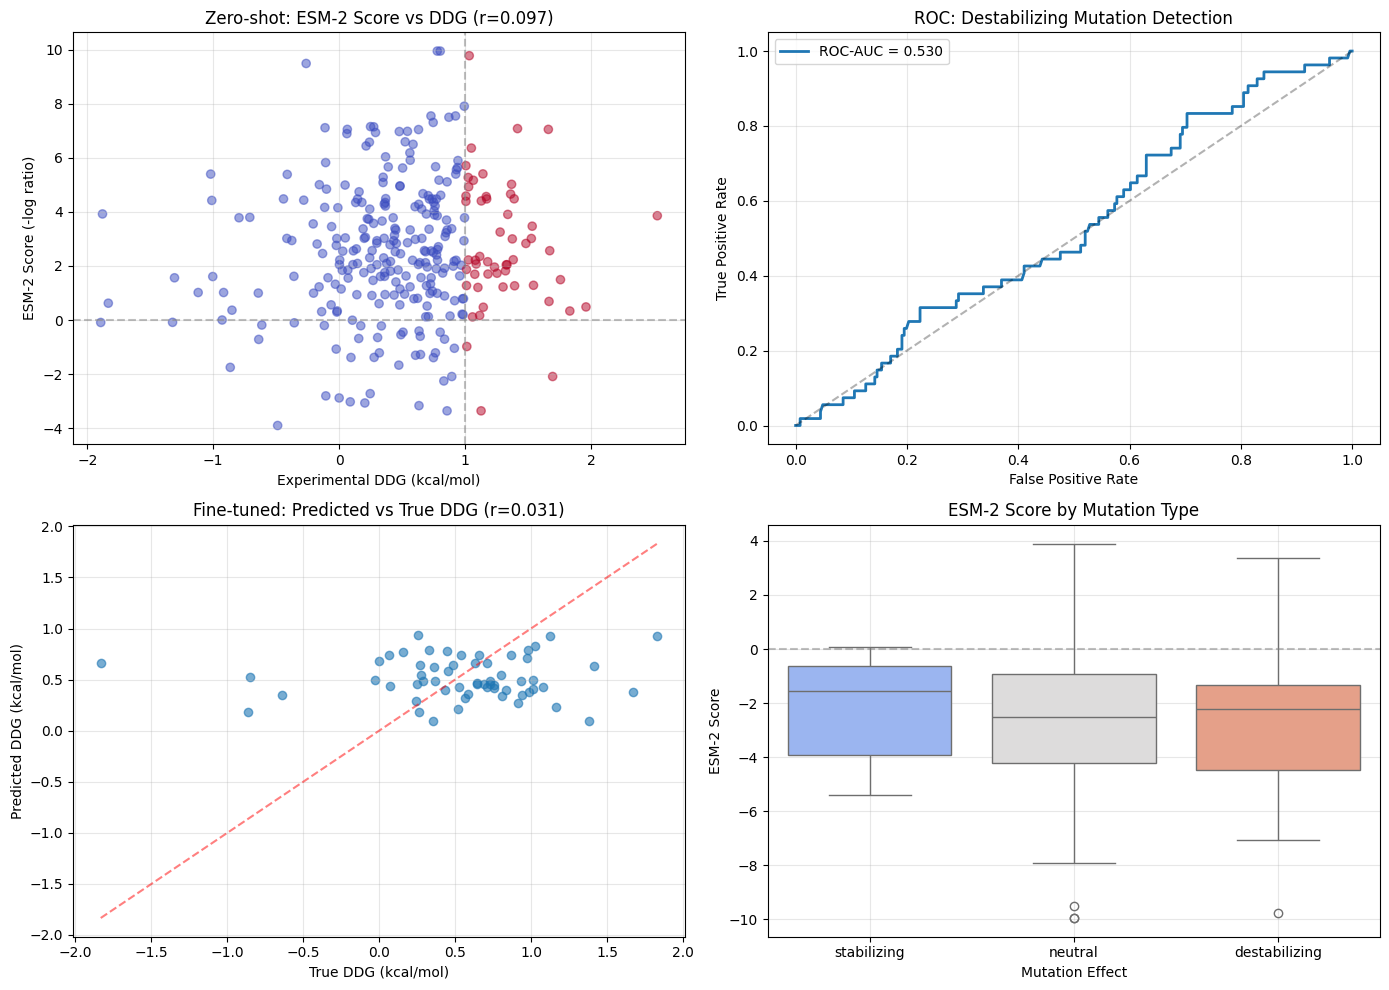

In [11]:
print("\n[6/6] Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Zero-shot score vs DDG scatter
axes[0, 0].scatter(df['ddg'], -df['esm_score'], alpha=0.5, c=df['destabilizing'], cmap='coolwarm')
axes[0, 0].axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Experimental DDG (kcal/mol)')
axes[0, 0].set_ylabel('ESM-2 Score (-log ratio)')
axes[0, 0].set_title(f'Zero-shot: ESM-2 Score vs DDG (r={corr:.3f})')
axes[0, 0].grid(alpha=0.3)
# 2. ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(df['destabilizing'], pred_score)
axes[0, 1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}', lw=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC: Destabilizing Mutation Detection')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Fine-tuned predictions
axes[1, 0].scatter(y_te, final_pred, alpha=0.6)
axes[1, 0].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', alpha=0.5)
axes[1, 0].set_xlabel('True DDG (kcal/mol)')
axes[1, 0].set_ylabel('Predicted DDG (kcal/mol)')
axes[1, 0].set_title(f'Fine-tuned: Predicted vs True DDG (r={final_r:.3f})')
axes[1, 0].grid(alpha=0.3)

# 4. Mutation type breakdown
df_melt = df.melt(id_vars=['label'], value_vars=['esm_score'], var_name='score_type', value_name='score')
sns.boxplot(data=df, x='label', y='esm_score', order=['stabilizing', 'neutral', 'destabilizing'],
            palette='coolwarm', ax=axes[1, 1])
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Mutation Effect')
axes[1, 1].set_ylabel('ESM-2 Score')
axes[1, 1].set_title('ESM-2 Score by Mutation Type')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('project3_mutation_esm2_results.png', dpi=150)
print("  [Saved] project3_mutation_esm2_results.png")
# plt.show()

print("\n" + "=" * 65)
print("PROJECT 3 COMPLETE")
print("=" * 65)

In [10]:
# 2. ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(df['destabilizing'], pred_score)
axes[0, 1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}', lw=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC: Destabilizing Mutation Detection')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)